In [14]:
import pandas as pd
import numpy as np
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import random

# Set the random seed for reproducibility
np.random.seed(42)
random.seed(42)

def generate_predictions(inference, test_data, threshold):
    predictions = []
    # Loop over test instances; for each, drop the target to create evidence.
    for idx, row in test_data.drop(columns=["default_indicator"]).iterrows():
        evidence = row.to_dict()
        posterior = inference.query(variables=['default_indicator'], evidence=evidence)
        # Assume that index 1 corresponds to the positive state.
        pred = 1 if posterior.values[1] > threshold else 0
        predictions.append(pred)
    return pd.Series(predictions, index=test_data.index)

# Define your columns
cols = [
    "grade", "emp_length", "home_ownership", "purpose", "default_indicator", "age_group"
]

# Load your data
data = pd.read_csv('rebalanced_age_data_discretized.csv')[cols]
data_no_na_default = data.dropna(subset=["default_indicator"])
data = data_no_na_default


# Define the network structure (edges)
edges = [
    ("grade", "default_indicator"),
    ("emp_length", "default_indicator"),
    ("home_ownership", "default_indicator"),
    ("purpose", "default_indicator"),
    ("age_group", "default_indicator")
]

# Bootstrapping settings
n_iterations = 100  # for a robust estimate, this might be increased to 500 or 1000
accuracy_samples = []
precision_samples = {0: [], 1: []}
recall_samples    = {0: [], 1: []}
f1_samples        = {0: [], 1: []}
conf_matrices     = []
fixed_threshold = 0.2

for i in range(n_iterations):
    # Create a random train-test split for each iteration
    train_data, test_data = train_test_split(data, test_size=0.02, random_state=random.randint(0, 10000))
    
    # Initialize and fit the Bayesian network model
    model = DiscreteBayesianNetwork(edges)
    model.fit(train_data, estimator=BayesianEstimator, prior_type='BDeu',  equivalent_sample_size=10000)
    
    # Prepare the test features
    test_features = test_data.drop(columns=["default_indicator"])
    test_data = test_data.dropna()

    y_true = test_data["default_indicator"]

    inference = VariableElimination(model)

    y_pred_bs = generate_predictions(inference, test_data, fixed_threshold)
    
    # Extract the ground truth for the bootstrap sample
    y_true_bs = y_true
    
    # Compute accuracy and append
    acc = accuracy_score(y_true_bs, y_pred_bs)
    accuracy_samples.append(acc)
    
    # Compute precision, recall, f1 for each class (assuming binary classification with labels [0, 1])
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_bs, y_pred_bs, labels=[0, 1], zero_division=0
    )
    precision_samples[0].append(precision[0])
    precision_samples[1].append(precision[1])
    recall_samples[0].append(recall[0])
    recall_samples[1].append(recall[1])
    f1_samples[0].append(f1[0])
    f1_samples[1].append(f1[1])

    conf = confusion_matrix(y_true_bs, y_pred_bs, labels=[0, 1])
    conf_matrices.append(conf)
    
    print(i)



INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}


0


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}


1


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}


...

96


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}


97


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}


98
99


In [4]:
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define the columns (features) as provided
cols = [
    "grade",
    "emp_length",
    "home_ownership",
    "purpose",
    "default_indicator",
    "age_group",
]

# Load your pre-discretized data
data = pd.read_csv('rebalanced_age_data_discretized.csv')

# Filter the data to include only the relevant columns
data = data[cols]

# Define a plausible structure for predicting default_indicator
edges = [
    ("grade", "default_indicator"),
    ("emp_length", "default_indicator"),
    ("home_ownership", "default_indicator"),
    ("purpose", "default_indicator"),
    ("age_group", "default_indicator")
]

# Initialize the Bayesian network with the assumed structure.
model = DiscreteBayesianNetwork(edges)

# Split the data into training and test sets.
# Stratify by the target column to maintain class proportions.
train_data, test_data = train_test_split(
    data,
    test_size=0.05,
    random_state=42
)

print(len(data))

# Fit the Bayesian network on the training data using Bayesian estimation.
model.fit(train_data, estimator=BayesianEstimator, prior_type='BDeu')

for cpd in model.get_cpds():
    # convert the TabularCPD into a pandas DataFrame
    # (pgmpy ≥0.1.14; if you’re on an older version, see notes below)
    cpd.to_csv(f"{cpd.variable}_cpd.csv")
    print(f"Saved {cpd.variable}_cpd.csv")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}


184212
Saved grade_cpd.csv
Saved default_indicator_cpd.csv
Saved emp_length_cpd.csv
Saved home_ownership_cpd.csv
Saved purpose_cpd.csv
Saved age_group_cpd.csv


In [3]:
import pandas as pd
df = pd.read_csv('default_indicator_cpd.csv')
df= df.sample(n=5, axis=1, random_state=42)
df.to_csv('random_5_columns_static_credit_default_naive.csv', index=False)

KeyboardInterrupt: 

In [4]:
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

cols = [
    "default_indicator",
    "gdp_growth_t1_disc",
    "unemployment_rate_t1_disc",
    "fedfunds_t1_disc",
    "inflation_t1_disc",
    "housing_price_t1_disc",
]

# Load your data and drop rows with missing target
data = pd.read_csv('rebalanced_age_data_discretized.csv')[cols]
data = data.dropna(subset=["default_indicator"])

# Define the network structure (edges)
edges = [
    ("gdp_growth_t1_disc", "default_indicator"),
    ("unemployment_rate_t1_disc", "default_indicator"),
    ("fedfunds_t1_disc", "default_indicator"),
    ("inflation_t1_disc", "default_indicator"),
    ("housing_price_t1_disc", "default_indicator"),
]

# Initialize the Bayesian network with the assumed structure.
model = DiscreteBayesianNetwork(edges)

# Split the data into training and test sets.
# Stratify by the target column to maintain class proportions.
train_data, test_data = train_test_split(
    data,
    test_size=0.05,
    random_state=42
)

print(len(data))

# Fit the Bayesian network on the training data using Bayesian estimation.
model.fit(train_data, estimator=BayesianEstimator, prior_type='BDeu')

for cpd in model.get_cpds():
    if cpd.variable == "default_indicator":
        cpd.to_csv(f"{cpd.variable}_cpd.csv")
        print(f"Saved {cpd.variable}_cpd.csv")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}


183893
Saved default_indicator_cpd.csv


In [5]:
df = pd.read_csv('default_indicator_cpd.csv')
df= df.sample(n=5, axis=1, random_state=42)
df.to_csv('random_5_columns_static_macro_naive.csv', index=False)

In [ ]:
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
cols = [
    "loan_amnt_disc",
    "int_rate_disc",
    "installment_disc",
    "pub_rec_disc",
    "revol_bal_disc",
    "revol_util_disc",
    "total_acc_disc",
    "annual_inc_disc",
    "delinq_2yrs_disc",
    "inq_last_6mths_disc",
    "open_acc_disc",
    #"grade",
    #"sub_grade",
    "fico_bucket_pct",
    "default_indicator",
    #"gdp_growth_t1_disc",
    #"unemployment_rate_t1_disc",
   # "fedfunds_t1_disc",
    #"inflation_t1_disc",
    #"housing_price_t1_disc",
]

# Load your data and drop rows with missing target
data = pd.read_csv('rebalanced_age_data_discretized.csv')[cols]
data = data.dropna(subset=["default_indicator"])
data = data[data['revol_util_disc'] != 2]

# Define the network structure (edges)
edges = [
    ("fico_bucket_pct", "default_indicator"),
    ("loan_amnt_disc","default_indicator"),
    ("int_rate_disc","default_indicator"),
    ("installment_disc","default_indicator"),
    ("pub_rec_disc","default_indicator"),
    ("revol_bal_disc","default_indicator"),
    ("revol_util_disc","default_indicator"),
    ("total_acc_disc","default_indicator"),
    ("annual_inc_disc","default_indicator"),
    ("delinq_2yrs_disc","default_indicator"),
    ("inq_last_6mths_disc","default_indicator"),
    ("open_acc_disc","default_indicator"),
]

# Initialize the Bayesian network with the assumed structure.
model = DiscreteBayesianNetwork(edges)

# Split the data into training and test sets.
# Stratify by the target column to maintain class proportions.
train_data, test_data = train_test_split(
    data,
    test_size=0.05,
    random_state=42
)

print(len(data))

# Fit the Bayesian network on the training data using Bayesian estimation.
model.fit(train_data, estimator=BayesianEstimator, prior_type='BDeu')

for cpd in model.get_cpds():
    if cpd.variable == "default_indicator":
        cpd.to_csv(f"{cpd.variable}_cpd.csv")
        print(f"Saved {cpd.variable}_cpd.csv")

In [16]:
# Function to compute confidence intervals from a list of values (2.5th and 97.5th percentiles)
def compute_ci(metric_samples, ci=[2.5, 97.5]):
    return np.percentile(metric_samples, ci)

# Compute 95% confidence interval for overall accuracy
ci_accuracy = compute_ci(accuracy_samples)
print("Fixed Threshold ({:.2f}) Performance:".format(fixed_threshold))
print("Classification Accuracy: {:.3f}".format(np.mean(accuracy_samples)))
print("95% CI for Accuracy: [{:.3f}, {:.3f}]".format(ci_accuracy[0], ci_accuracy[1]))

# Compute confidence intervals for precision, recall, and F1 for each class:
for label in [0, 1]:
    ci_precision = compute_ci(precision_samples[label])
    ci_recall    = compute_ci(recall_samples[label])
    ci_f1        = compute_ci(f1_samples[label])
    print("\nClass {} Metrics:".format(label))
    print("Precision: mean = {:.3f}, 95% CI = [{:.3f}, {:.3f}]".format(
        np.mean(precision_samples[label]), ci_precision[0], ci_precision[1]))
    print("Recall:    mean = {:.3f}, 95% CI = [{:.3f}, {:.3f}]".format(
        np.mean(recall_samples[label]), ci_recall[0], ci_recall[1]))
    print("F1 Score:  mean = {:.3f}, 95% CI = [{:.3f}, {:.3f}]".format(
        np.mean(f1_samples[label]), ci_f1[0], ci_f1[1]))
    

conf_matrices = np.stack(conf_matrices, axis=0)  # shape: (n_iterations, 2, 2)

# Define lists to collect the rates for each bootstrap sample.
tpr_samples = []
tnr_samples = []
fpr_samples = []
fnr_samples = []

# Loop over each confusion matrix from the bootstrap iterations.
for conf in conf_matrices:
    # Unpack the values. We assume the confusion matrix is arranged as:
    # [[TN, FP],
    #  [FN, TP]]
    TN = conf[0, 0]
    FP = conf[0, 1]
    FN = conf[1, 0]
    TP = conf[1, 1]
    
    # Compute rates, with guards in case the denominators are zero.
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # Sensitivity
    TNR = TN / (TN + FP) if (TN + FP) > 0 else 0.0  # Specificity
    FPR = FP / (TN + FP) if (TN + FP) > 0 else 0.0  # False Positive Rate
    FNR = FN / (TP + FN) if (TP + FN) > 0 else 0.0  # False Negative Rate
    
    tpr_samples.append(TPR)
    tnr_samples.append(TNR)
    fpr_samples.append(FPR)
    fnr_samples.append(FNR)

# Define a function to compute the confidence interval (e.g., the 2.5th and 97.5th percentiles)
def compute_ci(metric_samples, ci=[2.5, 97.5]):
    return np.percentile(metric_samples, ci)

# Calculate the means and 95% CIs for each rate.
mean_tpr = np.mean(tpr_samples)
ci_tpr = compute_ci(tpr_samples)

mean_tnr = np.mean(tnr_samples)
ci_tnr = compute_ci(tnr_samples)

mean_fpr = np.mean(fpr_samples)
ci_fpr = compute_ci(fpr_samples)

mean_fnr = np.mean(fnr_samples)
ci_fnr = compute_ci(fnr_samples)

print("False Positive Rate (FPR): mean = {:.3f}, 95% CI = [{:.3f}, {:.3f}]".format(
    mean_fpr, ci_fpr[0], ci_fpr[1]))

print("False Negative Rate (FNR): mean = {:.3f}, 95% CI = [{:.3f}, {:.3f}]".format(
    mean_fnr, ci_fnr[0], ci_fnr[1]))


Fixed Threshold (0.20) Performance:
Classification Accuracy: 0.665
95% CI for Accuracy: [0.646, 0.681]

Class 0 Metrics:
Precision: mean = 0.868, 95% CI = [0.854, 0.882]
Recall:    mean = 0.711, 95% CI = [0.691, 0.729]
F1 Score:  mean = 0.781, 95% CI = [0.767, 0.795]

Class 1 Metrics:
Precision: mean = 0.215, 95% CI = [0.192, 0.236]
Recall:    mean = 0.422, 95% CI = [0.381, 0.460]
F1 Score:  mean = 0.284, 95% CI = [0.260, 0.310]
False Positive Rate (FPR): mean = 0.289, 95% CI = [0.271, 0.309]
False Negative Rate (FNR): mean = 0.578, 95% CI = [0.540, 0.619]


In [ ]:
import pandas as pd
import numpy as np
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import random

# Set the random seed for reproducibility
np.random.seed(42)
random.seed(42)

def generate_predictions(inference, test_data, threshold):
    predictions = []
    # Loop over test instances; for each, drop the target to create evidence.
    for idx, row in test_data.drop(columns=["default_indicator"]).iterrows():
        evidence = row.to_dict()
        posterior = inference.query(variables=['default_indicator'], evidence=evidence)
        # Assume that index 1 corresponds to the positive state.
        pred = 1 if posterior.values[1] > threshold else 0
        predictions.append(pred)
    return pd.Series(predictions, index=test_data.index)

# Define your columns
cols = [
    "grade", "emp_length", "home_ownership", "purpose", "default_indicator", "age_group"
]

# Load your data and drop rows with missing target
data = pd.read_csv('rebalanced_age_data_discretized.csv')[cols]
data = data.dropna(subset=["default_indicator"])

# Define the network structure (edges)
edges = [
    ("grade", "default_indicator"),
    ("emp_length", "default_indicator"),
    ("home_ownership", "default_indicator"),
    ("purpose", "default_indicator"),
    ("age_group", "default_indicator")
]

# Define thresholds to test (from 0.15 to 0.50 in 0.05 increments)
thresholds = np.arange(0.15, 0.51, 0.05)

# Number of bootstrap iterations per threshold
n_iterations = 100  # Increase to 500 or 1000 for more robust estimates

# This list will collect results for each threshold.
results_list = []

# Function to compute 95% CI from a list of metric values
def compute_ci(metric_samples):
    return np.percentile(metric_samples, [2.5, 97.5])

# Loop over each fixed threshold
for thresh in thresholds:
    # Containers for metrics per bootstrap iteration
    accuracy_samples = []
    precision_samples = {0: [], 1: []}
    recall_samples    = {0: [], 1: []}
    f1_samples        = {0: [], 1: []}
    
    # Containers for confusion matrix derived rates
    tpr_samples = []  # True Positive Rate for class 1
    tnr_samples = []  # True Negative Rate for class 0
    fpr_samples = []  # False Positive Rate for class 0
    fnr_samples = []  # False Negative Rate for class 1

    # For each bootstrap iteration
    for i in range(n_iterations):
        # Create a random train-test split for this iteration
        train_data, test_data = train_test_split(data, test_size=0.02, random_state=random.randint(0, 10000))
        test_data = test_data.dropna()  # ensure no missing targets
        
        # Initialize and fit the Bayesian network model
        model = DiscreteBayesianNetwork(edges)
        model.fit(train_data, estimator=BayesianEstimator, prior_type='BDeu')
    
        # Prepare test features and ground truth
        y_true = test_data["default_indicator"]
    
        # Create an inference object
        inference = VariableElimination(model)
    
        # Generate predictions using the fixed threshold
        y_pred = generate_predictions(inference, test_data, thresh)
    
        # Compute accuracy
        acc = accuracy_score(y_true, y_pred)
        accuracy_samples.append(acc)
    
        # Compute precision, recall, f1 for each class (binary: 0 and 1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[0, 1], zero_division=0
        )
        precision_samples[0].append(precision[0])
        precision_samples[1].append(precision[1])
        recall_samples[0].append(recall[0])
        recall_samples[1].append(recall[1])
        f1_samples[0].append(f1[0])
        f1_samples[1].append(f1[1])
    
        # Compute the confusion matrix; assume label order [0, 1]
        conf = confusion_matrix(y_true, y_pred, labels=[0, 1])
        # Confusion matrix layout: [ [TN, FP],
        #                             [FN, TP] ]
        TN, FP = conf[0, 0], conf[0, 1]
        FN, TP = conf[1, 0], conf[1, 1]
        # Calculate rates with handling for zero denominators
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # Sensitivity
        TNR = TN / (TN + FP) if (TN + FP) > 0 else 0.0  # Specificity
        FPR = FP / (TN + FP) if (TN + FP) > 0 else 0.0
        FNR = FN / (TP + FN) if (TP + FN) > 0 else 0.0
    
        tpr_samples.append(TPR)
        tnr_samples.append(TNR)
        fpr_samples.append(FPR)
        fnr_samples.append(FNR)
    
    # Compute means and 95% confidence intervals for all metrics
    acc_mean = np.mean(accuracy_samples)
    acc_ci = compute_ci(accuracy_samples)
    
    precision_0_mean = np.mean(precision_samples[0])
    precision_0_ci = compute_ci(precision_samples[0])
    precision_1_mean = np.mean(precision_samples[1])
    precision_1_ci = compute_ci(precision_samples[1])
    
    recall_0_mean = np.mean(recall_samples[0])
    recall_0_ci = compute_ci(recall_samples[0])
    recall_1_mean = np.mean(recall_samples[1])
    recall_1_ci = compute_ci(recall_samples[1])
    
    f1_0_mean = np.mean(f1_samples[0])
    f1_0_ci = compute_ci(f1_samples[0])
    f1_1_mean = np.mean(f1_samples[1])
    f1_1_ci = compute_ci(f1_samples[1])
    
    tpr_mean = np.mean(tpr_samples)
    tpr_ci = compute_ci(tpr_samples)
    tnr_mean = np.mean(tnr_samples)
    tnr_ci = compute_ci(tnr_samples)
    fpr_mean = np.mean(fpr_samples)
    fpr_ci = compute_ci(fpr_samples)
    fnr_mean = np.mean(fnr_samples)
    fnr_ci = compute_ci(fnr_samples)
    
    # Save the results in a dictionary and add it to the list
    results_list.append({
        'threshold': thresh,
        'accuracy_mean': acc_mean,
        'accuracy_ci_lower': acc_ci[0],
        'accuracy_ci_upper': acc_ci[1],
        
        'precision_0_mean': precision_0_mean,
        'precision_0_ci_lower': precision_0_ci[0],
        'precision_0_ci_upper': precision_0_ci[1],
        
        'precision_1_mean': precision_1_mean,
        'precision_1_ci_lower': precision_1_ci[0],
        'precision_1_ci_upper': precision_1_ci[1],
        
        'recall_0_mean': recall_0_mean,
        'recall_0_ci_lower': recall_0_ci[0],
        'recall_0_ci_upper': recall_0_ci[1],
        
        'recall_1_mean': recall_1_mean,
        'recall_1_ci_lower': recall_1_ci[0],
        'recall_1_ci_upper': recall_1_ci[1],
        
        'f1_0_mean': f1_0_mean,
        'f1_0_ci_lower': f1_0_ci[0],
        'f1_0_ci_upper': f1_0_ci[1],
        
        'f1_1_mean': f1_1_mean,
        'f1_1_ci_lower': f1_1_ci[0],
        'f1_1_ci_upper': f1_1_ci[1],
        
        'TPR_mean': tpr_mean,
        'TPR_ci_lower': tpr_ci[0],
        'TPR_ci_upper': tpr_ci[1],
        
        'TNR_mean': tnr_mean,
        'TNR_ci_lower': tnr_ci[0],
        'TNR_ci_upper': tnr_ci[1],
        
        'FPR_mean': fpr_mean,
        'FPR_ci_lower': fpr_ci[0],
        'FPR_ci_upper': fpr_ci[1],
        
        'FNR_mean': fnr_mean,
        'FNR_ci_lower': fnr_ci[0],
        'FNR_ci_upper': fnr_ci[1],
    })
    
    print("Completed threshold =", thresh)

# Create a DataFrame from the results
results_df = pd.DataFrame(results_list)

results_df.to_csv('bootstrap_results.csv', index=False)


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade

Completed threshold = 0.15


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade

Completed threshold = 0.2


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade

...

Completed threshold = 0.40000000000000013


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade

Completed threshold = 0.45000000000000007


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'default_indicator': 'N', 'age_group': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'grade

Completed threshold = 0.5000000000000001


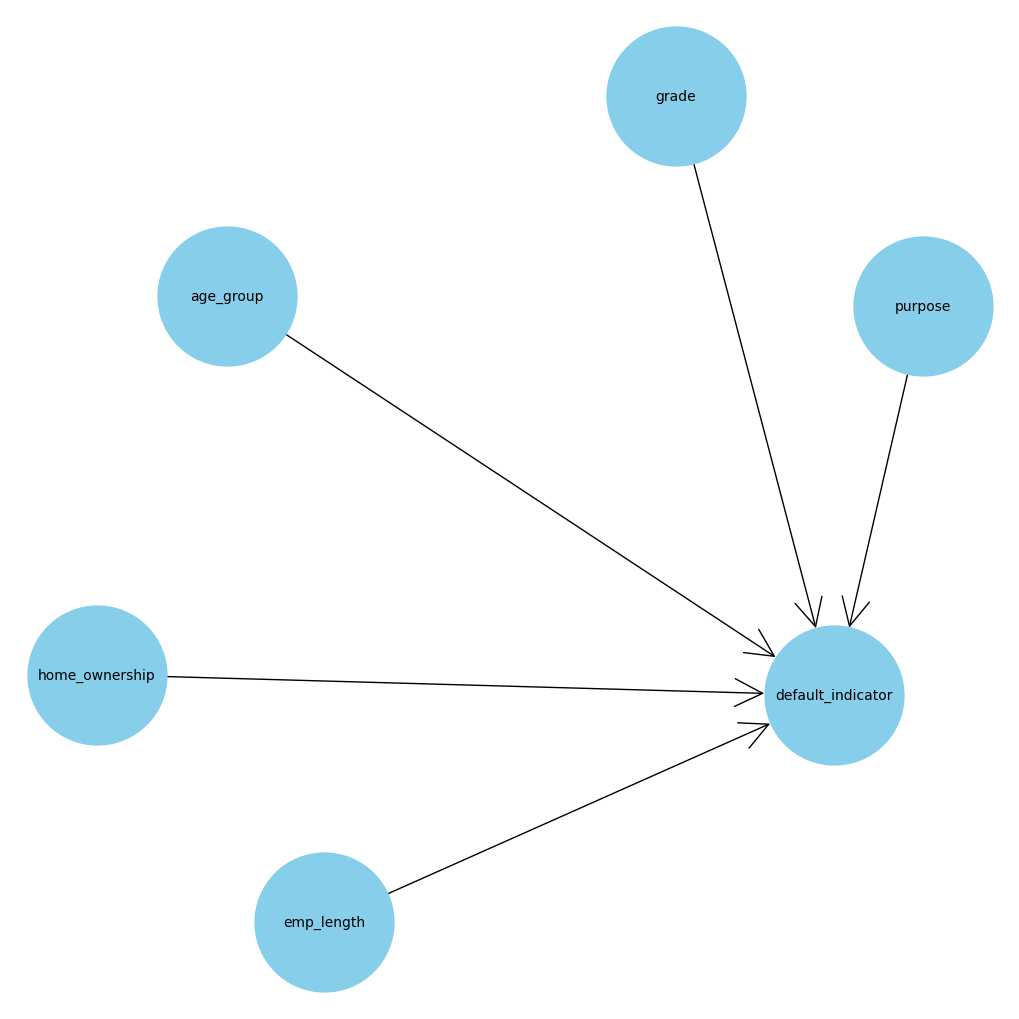

<Figure size 640x480 with 0 Axes>

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

edges = [
    ("grade", "default_indicator"),
    ("emp_length", "default_indicator"),
    ("home_ownership", "default_indicator"),
    ("purpose", "default_indicator"),
    ("age_group", "default_indicator")
]

# Assume 'all_edges' is your list of edges.
G = nx.DiGraph()  # Directed graph
G.add_edges_from(edges)

# Use spring_layout with increased 'k' value and a fixed seed for reproducibility.
# Adjust 'k' (try something like 0.5, 1, or even higher) to increase spacing.
pos = nx.spring_layout(G, k=1.5, seed=42)

plt.figure(figsize=(10, 10))  # Increase the figure size
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=10000,
    arrowstyle='->',
    arrowsize=50,
    font_size=10
)
plt.show()
plt.savefig('bayesian_network.png')

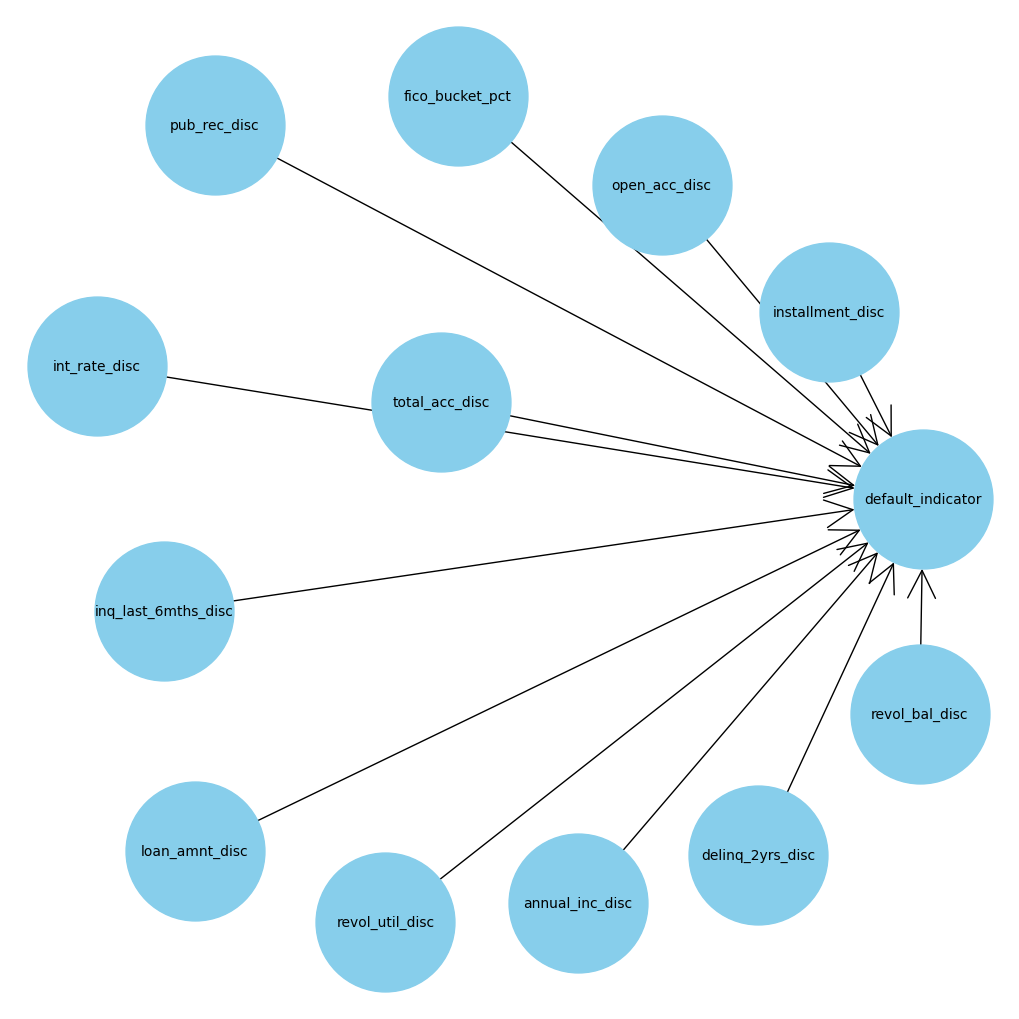

<Figure size 640x480 with 0 Axes>

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

edges = [
    ("fico_bucket_pct", "default_indicator"),
    ("loan_amnt_disc","default_indicator"),
    ("int_rate_disc","default_indicator"),
    ("installment_disc","default_indicator"),
    ("pub_rec_disc","default_indicator"),
    ("revol_bal_disc","default_indicator"),
    ("revol_util_disc","default_indicator"),
    ("total_acc_disc","default_indicator"),
    ("annual_inc_disc","default_indicator"),
    ("delinq_2yrs_disc","default_indicator"),
    ("inq_last_6mths_disc","default_indicator"),
    ("open_acc_disc","default_indicator"),
]

# Assume 'all_edges' is your list of edges.
G = nx.DiGraph()  # Directed graph
G.add_edges_from(edges)

# Use spring_layout with increased 'k' value and a fixed seed for reproducibility.
# Adjust 'k' (try something like 0.5, 1, or even higher) to increase spacing.
pos = nx.spring_layout(G, k=1.5, seed=42)

plt.figure(figsize=(10, 10))  # Increase the figure size
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=10000,
    arrowstyle='->',
    arrowsize=50,
    font_size=10
)
plt.show()
plt.savefig('bayesian_network.png')

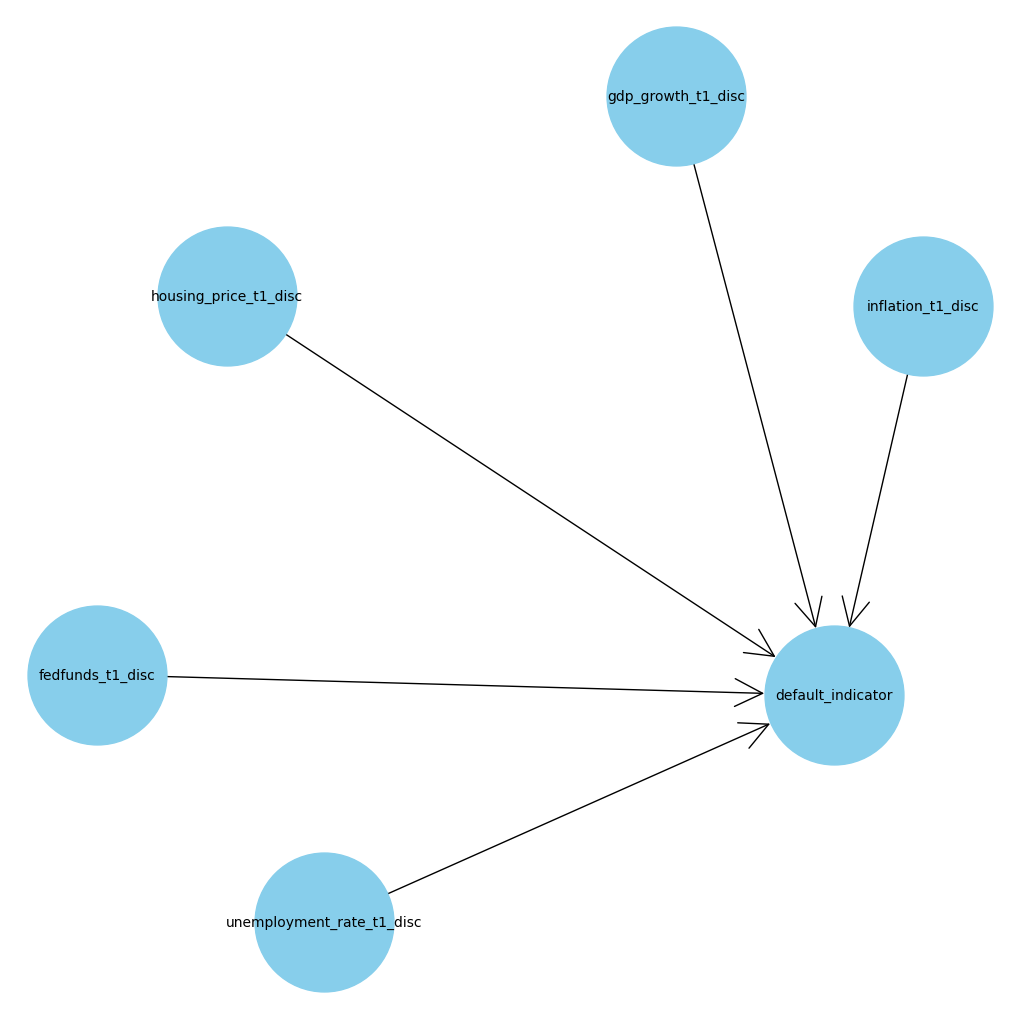

<Figure size 640x480 with 0 Axes>

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

edges = [
    ("gdp_growth_t1_disc", "default_indicator"),
    ("unemployment_rate_t1_disc", "default_indicator"),
    ("fedfunds_t1_disc", "default_indicator"),
    ("inflation_t1_disc", "default_indicator"),
    ("housing_price_t1_disc", "default_indicator"),
]

# Assume 'all_edges' is your list of edges.
G = nx.DiGraph()  # Directed graph
G.add_edges_from(edges)

# Use spring_layout with increased 'k' value and a fixed seed for reproducibility.
# Adjust 'k' (try something like 0.5, 1, or even higher) to increase spacing.
pos = nx.spring_layout(G, k=1.5, seed=42)

plt.figure(figsize=(10, 10))  # Increase the figure size
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=10000,
    arrowstyle='->',
    arrowsize=50,
    font_size=10
)
plt.show()
plt.savefig('bayesian_network.png')

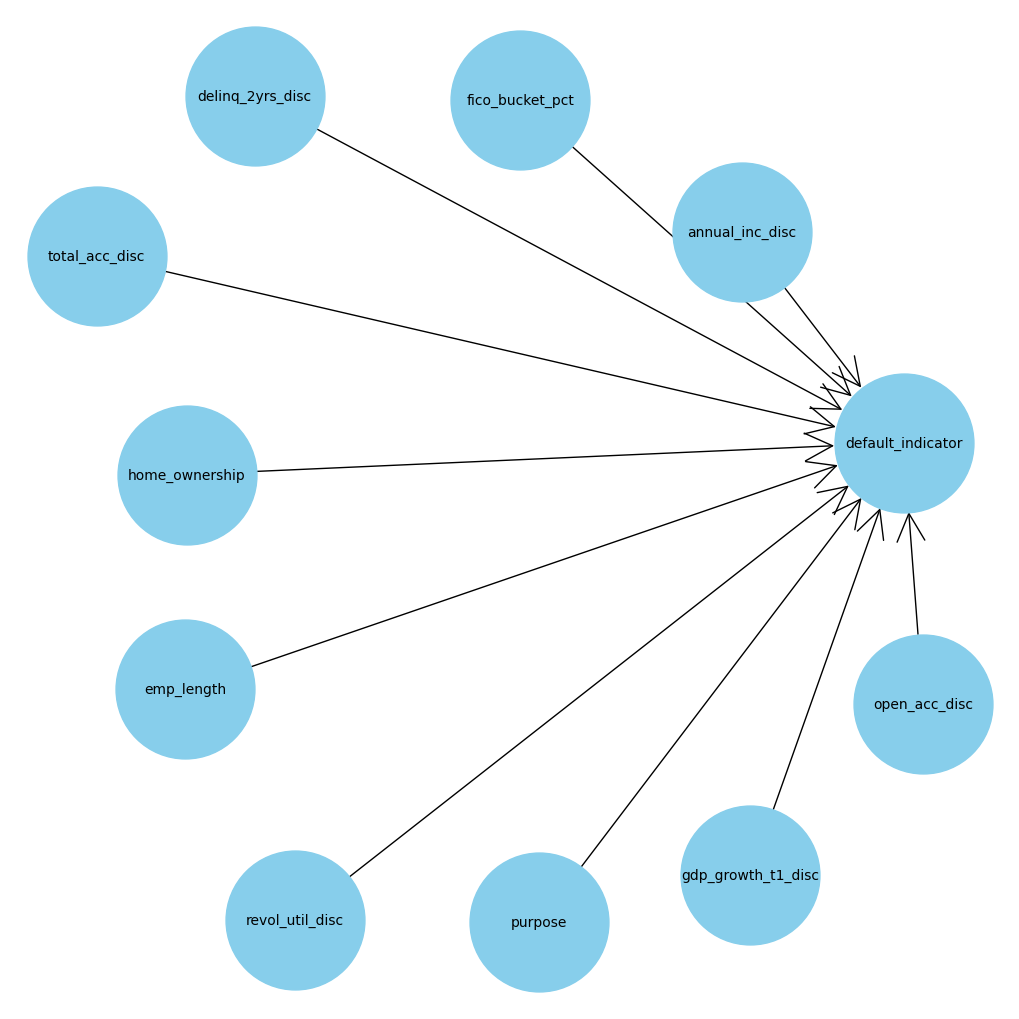

<Figure size 640x480 with 0 Axes>

In [12]:
edges = [
    ("fico_bucket_pct", "default_indicator"),
    ("revol_util_disc","default_indicator"),
    ("total_acc_disc","default_indicator"),
    ("annual_inc_disc","default_indicator"),
    ("delinq_2yrs_disc","default_indicator"),
    ("open_acc_disc","default_indicator"),
    ("emp_length","default_indicator"),
    ("home_ownership","default_indicator"),
    ("purpose","default_indicator"),
    ("gdp_growth_t1_disc", "default_indicator")
]

# Assume 'all_edges' is your list of edges.
G = nx.DiGraph()  # Directed graph
G.add_edges_from(edges)

# Use spring_layout with increased 'k' value and a fixed seed for reproducibility.
# Adjust 'k' (try something like 0.5, 1, or even higher) to increase spacing.
pos = nx.spring_layout(G, k=1.5, seed=42)

plt.figure(figsize=(10, 10))  # Increase the figure size
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=10000,
    arrowstyle='->',
    arrowsize=50,
    font_size=10
)
plt.show()
plt.savefig('bayesian_network.png')

In [ ]:
import pandas as pd
cols = [
    "grade", "emp_length", "home_ownership", "purpose", "default_indicator", "age_group"
]

# Load your data and drop rows with missing target
data = pd.read_csv('rebalanced_age_data_discretized.csv')[cols]
data = data.dropna(subset=["default_indicator"])
all_unique_values_in_data = data.drop(columns=["default_indicator"]).nunique()
print(all_unique_values_in_data)



grade              7
emp_length        11
home_ownership     6
purpose           14
age_group          6
dtype: int64


In [4]:
import pandas as pd
import numpy as np
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import random

# Set the random seed for reproducibility
np.random.seed(42)
random.seed(42)

def generate_predictions(inference, test_data, threshold):
    predictions = []
    # Loop over test instances; for each, drop the target to create evidence.
    for idx, row in test_data.drop(columns=["default_indicator"]).iterrows():
        evidence = row.to_dict()
        posterior = inference.query(variables=['default_indicator'], evidence=evidence)
        # Assume that index 1 corresponds to the positive state.
        pred = 1 if posterior.values[1] > threshold else 0
        predictions.append(pred)
    return pd.Series(predictions, index=test_data.index)

# Define your columns
cols = [
    "loan_amnt_disc",
    "int_rate_disc",
    "installment_disc",
    "pub_rec_disc",
    "revol_bal_disc",
    "revol_util_disc",
    "total_acc_disc",
    "annual_inc_disc",
    "delinq_2yrs_disc",
    "inq_last_6mths_disc",
    "open_acc_disc",
    #"grade",
    #"sub_grade",
    "fico_bucket_pct",
    "default_indicator",
    #"gdp_growth_t1_disc",
    #"unemployment_rate_t1_disc",
   # "fedfunds_t1_disc",
    #"inflation_t1_disc",
    #"housing_price_t1_disc",
]

# Load your data and drop rows with missing target
data = pd.read_csv('rebalanced_age_data_discretized.csv')[cols]
data = data.dropna(subset=["default_indicator"])
data = data[data['revol_util_disc'] != 2]

# Define the network structure (edges)
edges = [
    ("fico_bucket_pct", "default_indicator"),
    ("loan_amnt_disc","default_indicator"),
    ("int_rate_disc","default_indicator"),
    ("installment_disc","default_indicator"),
    ("pub_rec_disc","default_indicator"),
    ("revol_bal_disc","default_indicator"),
    ("revol_util_disc","default_indicator"),
    ("total_acc_disc","default_indicator"),
    ("annual_inc_disc","default_indicator"),
    ("delinq_2yrs_disc","default_indicator"),
    ("inq_last_6mths_disc","default_indicator"),
    ("open_acc_disc","default_indicator"),
]

# Define thresholds to test (from 0.15 to 0.50 in 0.05 increments)
thresholds = np.arange(0.2, 0.51, 0.05)

# Number of bootstrap iterations per threshold
n_iterations = 100  # Increase to 500 or 1000 for more robust estimates

# This list will collect results for each threshold.
results_list = []

# Function to compute 95% CI from a list of metric values
def compute_ci(metric_samples):
    return np.percentile(metric_samples, [2.5, 97.5])

# Loop over each fixed threshold
for thresh in thresholds:
    # Containers for metrics per bootstrap iteration
    accuracy_samples = []
    precision_samples = {0: [], 1: []}
    recall_samples    = {0: [], 1: []}
    f1_samples        = {0: [], 1: []}
    
    # Containers for confusion matrix derived rates
    tpr_samples = []  # True Positive Rate for class 1
    tnr_samples = []  # True Negative Rate for class 0
    fpr_samples = []  # False Positive Rate for class 0
    fnr_samples = []  # False Negative Rate for class 1

    # For each bootstrap iteration
    for i in range(n_iterations):
        # Create a random train-test split for this iteration
        train_data, test_data = train_test_split(data, test_size=0.02, random_state=random.randint(0, 10000),stratify=data["default_indicator"])
        test_data = test_data.dropna()  # ensure no missing targets
        
        # Initialize and fit the Bayesian network model
        model = DiscreteBayesianNetwork(edges)
        model.fit(train_data, estimator=BayesianEstimator, prior_type='BDeu')
    
        # Prepare test features and ground truth
        y_true = test_data["default_indicator"]
    
        # Create an inference object
        inference = VariableElimination(model)
    
        # Generate predictions using the fixed threshold
        y_pred = generate_predictions(inference, test_data, thresh)
    
        # Compute accuracy
        acc = accuracy_score(y_true, y_pred)
        accuracy_samples.append(acc)
    
        # Compute precision, recall, f1 for each class (binary: 0 and 1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[0, 1], zero_division=0
        )
        precision_samples[0].append(precision[0])
        precision_samples[1].append(precision[1])
        recall_samples[0].append(recall[0])
        recall_samples[1].append(recall[1])
        f1_samples[0].append(f1[0])
        f1_samples[1].append(f1[1])
    
        # Compute the confusion matrix; assume label order [0, 1]
        conf = confusion_matrix(y_true, y_pred, labels=[0, 1])
        # Confusion matrix layout: [ [TN, FP],
        #                             [FN, TP] ]
        TN, FP = conf[0, 0], conf[0, 1]
        FN, TP = conf[1, 0], conf[1, 1]
        # Calculate rates with handling for zero denominators
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # Sensitivity
        TNR = TN / (TN + FP) if (TN + FP) > 0 else 0.0  # Specificity
        FPR = FP / (TN + FP) if (TN + FP) > 0 else 0.0
        FNR = FN / (TP + FN) if (TP + FN) > 0 else 0.0
    
        tpr_samples.append(TPR)
        tnr_samples.append(TNR)
        fpr_samples.append(FPR)
        fnr_samples.append(FNR)
    
    # Compute means and 95% confidence intervals for all metrics
    acc_mean = np.mean(accuracy_samples)
    acc_ci = compute_ci(accuracy_samples)
    
    precision_0_mean = np.mean(precision_samples[0])
    precision_0_ci = compute_ci(precision_samples[0])
    precision_1_mean = np.mean(precision_samples[1])
    precision_1_ci = compute_ci(precision_samples[1])
    
    recall_0_mean = np.mean(recall_samples[0])
    recall_0_ci = compute_ci(recall_samples[0])
    recall_1_mean = np.mean(recall_samples[1])
    recall_1_ci = compute_ci(recall_samples[1])
    
    f1_0_mean = np.mean(f1_samples[0])
    f1_0_ci = compute_ci(f1_samples[0])
    f1_1_mean = np.mean(f1_samples[1])
    f1_1_ci = compute_ci(f1_samples[1])
    
    tpr_mean = np.mean(tpr_samples)
    tpr_ci = compute_ci(tpr_samples)
    tnr_mean = np.mean(tnr_samples)
    tnr_ci = compute_ci(tnr_samples)
    fpr_mean = np.mean(fpr_samples)
    fpr_ci = compute_ci(fpr_samples)
    fnr_mean = np.mean(fnr_samples)
    fnr_ci = compute_ci(fnr_samples)

    df_results = pd.read_csv('bootstrap_results.csv')
    
    # Save the results in a dictionary and add it to the list
    row = {
        'threshold': thresh,
        'accuracy_mean': acc_mean,
        'accuracy_ci_lower': acc_ci[0],
        'accuracy_ci_upper': acc_ci[1],
        
        'precision_0_mean': precision_0_mean,
        'precision_0_ci_lower': precision_0_ci[0],
        'precision_0_ci_upper': precision_0_ci[1],
        
        'precision_1_mean': precision_1_mean,
        'precision_1_ci_lower': precision_1_ci[0],
        'precision_1_ci_upper': precision_1_ci[1],
        
        'recall_0_mean': recall_0_mean,
        'recall_0_ci_lower': recall_0_ci[0],
        'recall_0_ci_upper': recall_0_ci[1],
        
        'recall_1_mean': recall_1_mean,
        'recall_1_ci_lower': recall_1_ci[0],
        'recall_1_ci_upper': recall_1_ci[1],
        
        'f1_0_mean': f1_0_mean,
        'f1_0_ci_lower': f1_0_ci[0],
        'f1_0_ci_upper': f1_0_ci[1],
        
        'f1_1_mean': f1_1_mean,
        'f1_1_ci_lower': f1_1_ci[0],
        'f1_1_ci_upper': f1_1_ci[1],
        
        'TPR_mean': tpr_mean,
        'TPR_ci_lower': tpr_ci[0],
        'TPR_ci_upper': tpr_ci[1],
        
        'TNR_mean': tnr_mean,
        'TNR_ci_lower': tnr_ci[0],
        'TNR_ci_upper': tnr_ci[1],
        
        'FPR_mean': fpr_mean,
        'FPR_ci_lower': fpr_ci[0],
        'FPR_ci_upper': fpr_ci[1],
        
        'FNR_mean': fnr_mean,
        'FNR_ci_lower': fnr_ci[0],
        'FNR_ci_upper': fnr_ci[1],
    }
    
    print("Completed threshold =", thresh)

    df_results.loc[len(df_results)] = row
    df_results.to_csv('bootstrap_results.csv', index=False)



INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'loan_amnt_disc': 'N', 'int_rate_disc': 'N', 'installment_disc': 'N', 'pub_rec_disc': 'N', 'revol_bal_disc': 'N', 'revol_util_disc': 'N', 'total_acc_disc': 'N', 'annual_inc_disc': 'N', 'delinq_2yrs_disc': 'N', 'inq_last_6mths_disc': 'N', 'open_acc_disc': 'N', 'fico_bucket_pct': 'C', 'default_indicator': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'loan_amnt_disc': 'N', 'int_rate_disc': 'N', 'installment_disc': 'N', 'pub_rec_disc': 'N', 'revol_bal_disc': 'N', 'revol_util_disc': 'N', 'total_acc_disc': 'N', 'annual_inc_disc': 'N', 'delinq_2yrs_disc': 'N', 'inq_last_6mths_disc': 'N', 'open_acc_disc': 'N', 'fico_bucket_pct': 'C', 'default_indicator': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'loan_amnt_disc': 'N', 'int_rate_disc': 'N', 'installment_disc

Completed threshold = 0.2


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'loan_amnt_disc': 'N', 'int_rate_disc': 'N', 'installment_disc': 'N', 'pub_rec_disc': 'N', 'revol_bal_disc': 'N', 'revol_util_disc': 'N', 'total_acc_disc': 'N', 'annual_inc_disc': 'N', 'delinq_2yrs_disc': 'N', 'inq_last_6mths_disc': 'N', 'open_acc_disc': 'N', 'fico_bucket_pct': 'C', 'default_indicator': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'loan_amnt_disc': 'N', 'int_rate_disc': 'N', 'installment_disc': 'N', 'pub_rec_disc': 'N', 'revol_bal_disc': 'N', 'revol_util_disc': 'N', 'total_acc_disc': 'N', 'annual_inc_disc': 'N', 'delinq_2yrs_disc': 'N', 'inq_last_6mths_disc': 'N', 'open_acc_disc': 'N', 'fico_bucket_pct': 'C', 'default_indicator': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'loan_amnt_disc': 'N', 'int_rate_disc': 'N', 'installment_disc

Completed threshold = 0.25


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'loan_amnt_disc': 'N', 'int_rate_disc': 'N', 'installment_disc': 'N', 'pub_rec_disc': 'N', 'revol_bal_disc': 'N', 'revol_util_disc': 'N', 'total_acc_disc': 'N', 'annual_inc_disc': 'N', 'delinq_2yrs_disc': 'N', 'inq_last_6mths_disc': 'N', 'open_acc_disc': 'N', 'fico_bucket_pct': 'C', 'default_indicator': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'loan_amnt_disc': 'N', 'int_rate_disc': 'N', 'installment_disc': 'N', 'pub_rec_disc': 'N', 'revol_bal_disc': 'N', 'revol_util_disc': 'N', 'total_acc_disc': 'N', 'annual_inc_disc': 'N', 'delinq_2yrs_disc': 'N', 'inq_last_6mths_disc': 'N', 'open_acc_disc': 'N', 'fico_bucket_pct': 'C', 'default_indicator': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'loan_amnt_disc': 'N', 'int_rate_disc': 'N', 'installment_disc

...

Completed threshold = 0.39999999999999997


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'loan_amnt_disc': 'N', 'int_rate_disc': 'N', 'installment_disc': 'N', 'pub_rec_disc': 'N', 'revol_bal_disc': 'N', 'revol_util_disc': 'N', 'total_acc_disc': 'N', 'annual_inc_disc': 'N', 'delinq_2yrs_disc': 'N', 'inq_last_6mths_disc': 'N', 'open_acc_disc': 'N', 'fico_bucket_pct': 'C', 'default_indicator': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'loan_amnt_disc': 'N', 'int_rate_disc': 'N', 'installment_disc': 'N', 'pub_rec_disc': 'N', 'revol_bal_disc': 'N', 'revol_util_disc': 'N', 'total_acc_disc': 'N', 'annual_inc_disc': 'N', 'delinq_2yrs_disc': 'N', 'inq_last_6mths_disc': 'N', 'open_acc_disc': 'N', 'fico_bucket_pct': 'C', 'default_indicator': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'loan_amnt_disc': 'N', 'int_rate_disc': 'N', 'installment_disc

Completed threshold = 0.44999999999999996


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'loan_amnt_disc': 'N', 'int_rate_disc': 'N', 'installment_disc': 'N', 'pub_rec_disc': 'N', 'revol_bal_disc': 'N', 'revol_util_disc': 'N', 'total_acc_disc': 'N', 'annual_inc_disc': 'N', 'delinq_2yrs_disc': 'N', 'inq_last_6mths_disc': 'N', 'open_acc_disc': 'N', 'fico_bucket_pct': 'C', 'default_indicator': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'loan_amnt_disc': 'N', 'int_rate_disc': 'N', 'installment_disc': 'N', 'pub_rec_disc': 'N', 'revol_bal_disc': 'N', 'revol_util_disc': 'N', 'total_acc_disc': 'N', 'annual_inc_disc': 'N', 'delinq_2yrs_disc': 'N', 'inq_last_6mths_disc': 'N', 'open_acc_disc': 'N', 'fico_bucket_pct': 'C', 'default_indicator': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'loan_amnt_disc': 'N', 'int_rate_disc': 'N', 'installment_disc

Completed threshold = 0.49999999999999994


In [7]:
import pandas as pd
import numpy as np
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import random

# Set the random seed for reproducibility
np.random.seed(42)
random.seed(42)

def generate_predictions(inference, test_data, threshold):
    predictions = []
    # Loop over test instances; for each, drop the target to create evidence.
    for idx, row in test_data.drop(columns=["default_indicator"]).iterrows():
        evidence = row.to_dict()
        posterior = inference.query(variables=['default_indicator'], evidence=evidence)
        # Assume that index 1 corresponds to the positive state.
        pred = 1 if posterior.values[1] > threshold else 0
        predictions.append(pred)
    return pd.Series(predictions, index=test_data.index)

    '''
    "loan_amnt_disc",
    "int_rate_disc",
    "installment_disc",
    "pub_rec_disc",
    "revol_bal_disc",
    "revol_util_disc",
    "total_acc_disc",
    "annual_inc_disc",
    "delinq_2yrs_disc",
    "inq_last_6mths_disc",
    "open_acc_disc",
    "grade",
    #"sub_grade",
    "fico_bucket_pct",
    '''
# Define your columns
cols = [
    "default_indicator",
    "gdp_growth_t1_disc",
    "unemployment_rate_t1_disc",
    "fedfunds_t1_disc",
    "inflation_t1_disc",
    "housing_price_t1_disc",
]

# Load your data and drop rows with missing target
data = pd.read_csv('rebalanced_age_data_discretized.csv')[cols]
data = data.dropna(subset=["default_indicator"])

# Define the network structure (edges)
edges = [
    ("gdp_growth_t1_disc", "default_indicator"),
    ("unemployment_rate_t1_disc", "default_indicator"),
    ("fedfunds_t1_disc", "default_indicator"),
    ("inflation_t1_disc", "default_indicator"),
    ("housing_price_t1_disc", "default_indicator"),
]

# Define thresholds to test (from 0.15 to 0.50 in 0.05 increments)
thresholds = np.arange(0.2, 0.51, 0.05)

# Number of bootstrap iterations per threshold
n_iterations = 100  # Increase to 500 or 1000 for more robust estimates

# This list will collect results for each threshold.
results_list = []

# Function to compute 95% CI from a list of metric values
def compute_ci(metric_samples):
    return np.percentile(metric_samples, [2.5, 97.5])

# Loop over each fixed threshold
for thresh in thresholds:
    # Containers for metrics per bootstrap iteration
    accuracy_samples = []
    precision_samples = {0: [], 1: []}
    recall_samples    = {0: [], 1: []}
    f1_samples        = {0: [], 1: []}
    
    # Containers for confusion matrix derived rates
    tpr_samples = []  # True Positive Rate for class 1
    tnr_samples = []  # True Negative Rate for class 0
    fpr_samples = []  # False Positive Rate for class 0
    fnr_samples = []  # False Negative Rate for class 1

    # For each bootstrap iteration
    for i in range(n_iterations):
        # Create a random train-test split for this iteration
        train_data, test_data = train_test_split(data, test_size=0.02, random_state=random.randint(0, 10000),stratify=data["default_indicator"])
        test_data = test_data.dropna()  # ensure no missing targets
        
        # Initialize and fit the Bayesian network model
        model = DiscreteBayesianNetwork(edges)
        model.fit(train_data, estimator=BayesianEstimator, prior_type='BDeu')
    
        # Prepare test features and ground truth
        y_true = test_data["default_indicator"]
    
        # Create an inference object
        inference = VariableElimination(model)
    
        # Generate predictions using the fixed threshold
        y_pred = generate_predictions(inference, test_data, thresh)
    
        # Compute accuracy
        acc = accuracy_score(y_true, y_pred)
        accuracy_samples.append(acc)
    
        # Compute precision, recall, f1 for each class (binary: 0 and 1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[0, 1], zero_division=0
        )
        precision_samples[0].append(precision[0])
        precision_samples[1].append(precision[1])
        recall_samples[0].append(recall[0])
        recall_samples[1].append(recall[1])
        f1_samples[0].append(f1[0])
        f1_samples[1].append(f1[1])
    
        # Compute the confusion matrix; assume label order [0, 1]
        conf = confusion_matrix(y_true, y_pred, labels=[0, 1])
        # Confusion matrix layout: [ [TN, FP],
        #                             [FN, TP] ]
        TN, FP = conf[0, 0], conf[0, 1]
        FN, TP = conf[1, 0], conf[1, 1]
        # Calculate rates with handling for zero denominators
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # Sensitivity
        TNR = TN / (TN + FP) if (TN + FP) > 0 else 0.0  # Specificity
        FPR = FP / (TN + FP) if (TN + FP) > 0 else 0.0
        FNR = FN / (TP + FN) if (TP + FN) > 0 else 0.0
    
        tpr_samples.append(TPR)
        tnr_samples.append(TNR)
        fpr_samples.append(FPR)
        fnr_samples.append(FNR)
    
    # Compute means and 95% confidence intervals for all metrics
    acc_mean = np.mean(accuracy_samples)
    acc_ci = compute_ci(accuracy_samples)
    
    precision_0_mean = np.mean(precision_samples[0])
    precision_0_ci = compute_ci(precision_samples[0])
    precision_1_mean = np.mean(precision_samples[1])
    precision_1_ci = compute_ci(precision_samples[1])
    
    recall_0_mean = np.mean(recall_samples[0])
    recall_0_ci = compute_ci(recall_samples[0])
    recall_1_mean = np.mean(recall_samples[1])
    recall_1_ci = compute_ci(recall_samples[1])
    
    f1_0_mean = np.mean(f1_samples[0])
    f1_0_ci = compute_ci(f1_samples[0])
    f1_1_mean = np.mean(f1_samples[1])
    f1_1_ci = compute_ci(f1_samples[1])
    
    tpr_mean = np.mean(tpr_samples)
    tpr_ci = compute_ci(tpr_samples)
    tnr_mean = np.mean(tnr_samples)
    tnr_ci = compute_ci(tnr_samples)
    fpr_mean = np.mean(fpr_samples)
    fpr_ci = compute_ci(fpr_samples)
    fnr_mean = np.mean(fnr_samples)
    fnr_ci = compute_ci(fnr_samples)
    
    results_list.append({
        'threshold': thresh,
        'accuracy_mean': acc_mean,
        'accuracy_ci_lower': acc_ci[0],
        'accuracy_ci_upper': acc_ci[1],
        
        'precision_0_mean': precision_0_mean,
        'precision_0_ci_lower': precision_0_ci[0],
        'precision_0_ci_upper': precision_0_ci[1],
        
        'precision_1_mean': precision_1_mean,
        'precision_1_ci_lower': precision_1_ci[0],
        'precision_1_ci_upper': precision_1_ci[1],
        
        'recall_0_mean': recall_0_mean,
        'recall_0_ci_lower': recall_0_ci[0],
        'recall_0_ci_upper': recall_0_ci[1],
        
        'recall_1_mean': recall_1_mean,
        'recall_1_ci_lower': recall_1_ci[0],
        'recall_1_ci_upper': recall_1_ci[1],
        
        'f1_0_mean': f1_0_mean,
        'f1_0_ci_lower': f1_0_ci[0],
        'f1_0_ci_upper': f1_0_ci[1],
        
        'f1_1_mean': f1_1_mean,
        'f1_1_ci_lower': f1_1_ci[0],
        'f1_1_ci_upper': f1_1_ci[1],
        
        'TPR_mean': tpr_mean,
        'TPR_ci_lower': tpr_ci[0],
        'TPR_ci_upper': tpr_ci[1],
        
        'TNR_mean': tnr_mean,
        'TNR_ci_lower': tnr_ci[0],
        'TNR_ci_upper': tnr_ci[1],
        
        'FPR_mean': fpr_mean,
        'FPR_ci_lower': fpr_ci[0],
        'FPR_ci_upper': fpr_ci[1],
        
        'FNR_mean': fnr_mean,
        'FNR_ci_lower': fnr_ci[0],
        'FNR_ci_upper': fnr_ci[1],
    })
    
    print("Completed threshold =", thresh)

# Create a DataFrame from the results
results_df = pd.DataFrame(results_list)

results_df.to_csv('bootstrap_results_macro.csv', index=False)


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_

Completed threshold = 0.2


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_

Completed threshold = 0.25


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_

...

Completed threshold = 0.39999999999999997


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_

Completed threshold = 0.44999999999999996


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_t1_disc': 'N', 'fedfunds_t1_disc': 'N', 'inflation_t1_disc': 'N', 'housing_price_t1_disc': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'default_indicator': 'N', 'gdp_growth_t1_disc': 'N', 'unemployment_rate_

Completed threshold = 0.49999999999999994


In [6]:
import pandas as pd
import numpy as np
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import random

# Set the random seed for reproducibility
np.random.seed(42)
random.seed(42)

def generate_predictions(inference, test_data, threshold):
    predictions = []
    # Loop over test instances; for each, drop the target to create evidence.
    for idx, row in test_data.drop(columns=["default_indicator"]).iterrows():
        evidence = row.to_dict()
        posterior = inference.query(variables=['default_indicator'], evidence=evidence)
        # Assume that index 1 corresponds to the positive state.
        pred = 1 if posterior.values[1] > threshold else 0
        predictions.append(pred)
    return pd.Series(predictions, index=test_data.index)

# Define your columns
cols = [
    #"loan_amnt_disc",
    #"int_rate_disc",
    #"installment_disc",
    #"pub_rec_disc",
    #"revol_bal_disc",
    "revol_util_disc",
    "total_acc_disc",
    "annual_inc_disc",
    "delinq_2yrs_disc",
    #"inq_last_6mths_disc",
    "open_acc_disc",
    #"grade",
    "emp_length",
    "home_ownership",
    "purpose",
    #"sub_grade",
    "fico_bucket_pct",
    "default_indicator",
    "gdp_growth_t1_disc",
    #"unemployment_rate_t1_disc",
   # "fedfunds_t1_disc",
    #"inflation_t1_disc",
    #"housing_price_t1_disc",
]



# Load your data and drop rows with missing target
data = pd.read_csv('rebalanced_age_data_discretized.csv')[cols]
data = data.dropna(subset=["default_indicator"])
data = data.dropna(subset=["emp_length"])
data = data[data['revol_util_disc'] != 2]
data["revol_util_disc"] = data["revol_util_disc"].astype('category')
data["total_acc_disc"] = data["total_acc_disc"].astype('category')
data["annual_inc_disc"] = data["annual_inc_disc"].astype('category')
data["delinq_2yrs_disc"] = data["delinq_2yrs_disc"].astype('category')
data["open_acc_disc"] = data["open_acc_disc"].astype('category')
data["gdp_growth_t1_disc"] = data["gdp_growth_t1_disc"].astype('category')


# Define the network structure (edges)
edges = [
    ("fico_bucket_pct", "default_indicator"),
    ("revol_util_disc","default_indicator"),
    ("total_acc_disc","default_indicator"),
    ("annual_inc_disc","default_indicator"),
    ("delinq_2yrs_disc","default_indicator"),
    ("open_acc_disc","default_indicator"),
    ("emp_length","default_indicator"),
    ("home_ownership","default_indicator"),
    ("purpose","default_indicator"),
    ("gdp_growth_t1_disc", "default_indicator")
]

# Define thresholds to test (from 0.15 to 0.50 in 0.05 increments)
thresholds = [0.15]

# Number of bootstrap iterations per threshold
n_iterations = 100  # Increase to 500 or 1000 for more robust estimates

# This list will collect results for each threshold.
results_list = []

# Function to compute 95% CI from a list of metric values
def compute_ci(metric_samples):
    return np.percentile(metric_samples, [2.5, 97.5])

# Loop over each fixed threshold
for thresh in thresholds:
    # Containers for metrics per bootstrap iteration
    accuracy_samples = []
    precision_samples = {0: [], 1: []}
    recall_samples    = {0: [], 1: []}
    f1_samples        = {0: [], 1: []}
    
    # Containers for confusion matrix derived rates
    tpr_samples = []  # True Positive Rate for class 1
    tnr_samples = []  # True Negative Rate for class 0
    fpr_samples = []  # False Positive Rate for class 0
    fnr_samples = []  # False Negative Rate for class 1

    # For each bootstrap iteration
    for i in range(n_iterations):
        # Create a random train-test split for this iteration
        train_data, test_data = train_test_split(data, test_size=0.02, random_state=random.randint(0, 10000),stratify=data["default_indicator"])
        test_data = test_data.dropna()  # ensure no missing targets
        
        # Initialize and fit the Bayesian network model
        model = DiscreteBayesianNetwork(edges)
        model.fit(train_data, estimator=BayesianEstimator, prior_type='BDeu')
    
        # Prepare test features and ground truth
        y_true = test_data["default_indicator"]
    
        # Create an inference object
        inference = VariableElimination(model)
    
        # Generate predictions using the fixed threshold
        y_pred = generate_predictions(inference, test_data, thresh)
    
        # Compute accuracy
        acc = accuracy_score(y_true, y_pred)
        accuracy_samples.append(acc)
    
        # Compute precision, recall, f1 for each class (binary: 0 and 1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[0, 1], zero_division=0
        )
        precision_samples[0].append(precision[0])
        precision_samples[1].append(precision[1])
        recall_samples[0].append(recall[0])
        recall_samples[1].append(recall[1])
        f1_samples[0].append(f1[0])
        f1_samples[1].append(f1[1])
    
        # Compute the confusion matrix; assume label order [0, 1]
        conf = confusion_matrix(y_true, y_pred, labels=[0, 1])
        # Confusion matrix layout: [ [TN, FP],
        #                             [FN, TP] ]
        TN, FP = conf[0, 0], conf[0, 1]
        FN, TP = conf[1, 0], conf[1, 1]
        # Calculate rates with handling for zero denominators
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # Sensitivity
        TNR = TN / (TN + FP) if (TN + FP) > 0 else 0.0  # Specificity
        FPR = FP / (TN + FP) if (TN + FP) > 0 else 0.0
        FNR = FN / (TP + FN) if (TP + FN) > 0 else 0.0
    
        tpr_samples.append(TPR)
        tnr_samples.append(TNR)
        fpr_samples.append(FPR)
        fnr_samples.append(FNR)
    
    # Compute means and 95% confidence intervals for all metrics
    acc_mean = np.mean(accuracy_samples)
    acc_ci = compute_ci(accuracy_samples)
    
    precision_0_mean = np.mean(precision_samples[0])
    precision_0_ci = compute_ci(precision_samples[0])
    precision_1_mean = np.mean(precision_samples[1])
    precision_1_ci = compute_ci(precision_samples[1])
    
    recall_0_mean = np.mean(recall_samples[0])
    recall_0_ci = compute_ci(recall_samples[0])
    recall_1_mean = np.mean(recall_samples[1])
    recall_1_ci = compute_ci(recall_samples[1])
    
    f1_0_mean = np.mean(f1_samples[0])
    f1_0_ci = compute_ci(f1_samples[0])
    f1_1_mean = np.mean(f1_samples[1])
    f1_1_ci = compute_ci(f1_samples[1])
    
    tpr_mean = np.mean(tpr_samples)
    tpr_ci = compute_ci(tpr_samples)
    tnr_mean = np.mean(tnr_samples)
    tnr_ci = compute_ci(tnr_samples)
    fpr_mean = np.mean(fpr_samples)
    fpr_ci = compute_ci(fpr_samples)
    fnr_mean = np.mean(fnr_samples)
    fnr_ci = compute_ci(fnr_samples)

    df_results = pd.read_csv('bootstrap_results.csv')
    
    # Save the results in a dictionary and add it to the list
    row = {
        'threshold': thresh,
        'accuracy_mean': acc_mean,
        'accuracy_ci_lower': acc_ci[0],
        'accuracy_ci_upper': acc_ci[1],
        
        'precision_0_mean': precision_0_mean,
        'precision_0_ci_lower': precision_0_ci[0],
        'precision_0_ci_upper': precision_0_ci[1],
        
        'precision_1_mean': precision_1_mean,
        'precision_1_ci_lower': precision_1_ci[0],
        'precision_1_ci_upper': precision_1_ci[1],
        
        'recall_0_mean': recall_0_mean,
        'recall_0_ci_lower': recall_0_ci[0],
        'recall_0_ci_upper': recall_0_ci[1],
        
        'recall_1_mean': recall_1_mean,
        'recall_1_ci_lower': recall_1_ci[0],
        'recall_1_ci_upper': recall_1_ci[1],
        
        'f1_0_mean': f1_0_mean,
        'f1_0_ci_lower': f1_0_ci[0],
        'f1_0_ci_upper': f1_0_ci[1],
        
        'f1_1_mean': f1_1_mean,
        'f1_1_ci_lower': f1_1_ci[0],
        'f1_1_ci_upper': f1_1_ci[1],
        
        'TPR_mean': tpr_mean,
        'TPR_ci_lower': tpr_ci[0],
        'TPR_ci_upper': tpr_ci[1],
        
        'TNR_mean': tnr_mean,
        'TNR_ci_lower': tnr_ci[0],
        'TNR_ci_upper': tnr_ci[1],
        
        'FPR_mean': fpr_mean,
        'FPR_ci_lower': fpr_ci[0],
        'FPR_ci_upper': fpr_ci[1],
        
        'FNR_mean': fnr_mean,
        'FNR_ci_lower': fnr_ci[0],
        'FNR_ci_upper': fnr_ci[1],
    }
    
    print("Completed threshold =", thresh)

    df_results.loc[len(df_results)] = row
    df_results.to_csv('bootstrap_results.csv', index=False)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'revol_util_disc': 'C', 'total_acc_disc': 'C', 'annual_inc_disc': 'C', 'delinq_2yrs_disc': 'C', 'open_acc_disc': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'fico_bucket_pct': 'C', 'default_indicator': 'N', 'gdp_growth_t1_disc': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'revol_util_disc': 'C', 'total_acc_disc': 'C', 'annual_inc_disc': 'C', 'delinq_2yrs_disc': 'C', 'open_acc_disc': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 'fico_bucket_pct': 'C', 'default_indicator': 'N', 'gdp_growth_t1_disc': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'revol_util_disc': 'C', 'total_acc_disc': 'C', 'annual_inc_disc': 'C', 'delinq_2yrs_disc': 'C', 'open_acc_disc': 'C', 'emp_length': 'C', 'home_ownership': 'C', 'purpose': 'C', 

Completed threshold = 0.15
